<a href="https://colab.research.google.com/github/24f3004086/Image-Classification/blob/main/ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir dataset
!mv archive.zip dataset

mkdir: cannot create directory ‘dataset’: File exists
mv: cannot stat 'archive.zip': No such file or directory


In [ ]:
!cd dataset

In [ ]:
!file archive.zip

archive.zip: cannot open `archive.zip' (No such file or directory)


In [ ]:
!unzip dataset/archive.zip

Archive:  dataset/archive.zip
replace data/with_mask/with_mask_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

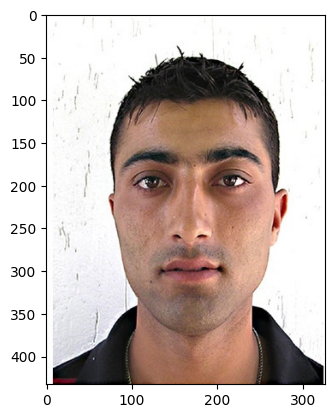

In [ ]:
file_path = 'data/without_mask/without_mask_673.jpg'
image = Image.open(file_path)
plt.imshow(image)

In [ ]:
def load_images(data_dir, target_size=(100, 100)):
  images = []
  labels = []

  class_names = os.listdir(data_dir)
  for class_name in class_names:
    class_dir = os.path.join(data_dir, class_name)
    for image_name in os.listdir(class_dir):
      image_path = os.path.join(class_dir, image_name)
      try:
        image = Image.open(image_path).resize(target_size).convert('L')
        image_array = np.array(image).flatten()/255.0
        # print (image_array.shape)

        # add images to image list along with class label in label list.
        images.append(image_array)
        labels.append(class_name)
      except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        continue

  return np.array(images), np.array(labels)

In [ ]:
images, labels = load_images('/content/data')

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
labels = pd.DataFrame(labels)
labels

,0
0,without_mask
1,without_mask
2,without_mask
3,without_mask
4,without_mask
...,...
7548,with_mask
7549,with_mask
7550,with_mask
7551,with_mask


In [ ]:
labels.value_counts()

,count
0,
without_mask,3828
with_mask,3725


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)
labels

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=0)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('rf', LogisticRegression(random_state=0, max_iter=500, tol=0.001, C=10))
])

In [ ]:
pipeline.fit(train_images, train_labels)

Pipeline(steps=[('rf',
                 LogisticRegression(C=10, max_iter=500, random_state=0,
                                    tol=0.001))])

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, pipeline.predict(test_images))
cm

array([[475, 270],
       [233, 533]])

In [ ]:
import random

def augment_data(images, labels,angle = (2 * len(images)), augmentation_factor=2):
  augmented_images = []
  augmented_labels = []

  for image, label in zip(images, labels):
    augmented_images.append(image)
    augmented_labels.append(label)

    for _ in range(augmentation_factor):
      angle = random.uniform(-180, 180)
      img = Image.fromarray((image.reshape((100, 100))*255).astype(np.uint8))

      # rotate the image
      img = img.rotate(angle)
      rotated_image = np.array(img).flatten()/255.0

      # add rotated image
      augmented_images.append(rotated_image)
      augmented_labels.append(label)

  return np.array(augmented_images), np.array(augmented_labels)

In [ ]:
x_train_augmented, y_train_augmented = augment_data(train_images, train_labels)

In [ ]:
y_train_augmented[7000:8000].sum()

np.int64(485)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)
rf.fit(x_train_augmented, y_train_augmented)

RandomForestClassifier(random_state=0)

In [ ]:
import numpy as np

importances = rf.feature_importances_

top_100_idx = np.argsort(importances)[-100:]

In [ ]:
X_train_top = x_train_augmented[:, top_100_idx]
X_test_top = test_images[:, top_100_idx]

In [ ]:
rf_final = RandomForestClassifier(random_state=0)
rf_final.fit(X_train_top,y_train_augmented)

RandomForestClassifier(random_state=0)

In [ ]:
y_pred = rf_final.predict(X_test_top)

misclassified = np.sum(y_pred != test_labels)
print(misclassified)

300


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100, random_state=0)

X_train_pca = pca.fit_transform(x_train_augmented)
X_test_pca = pca.transform(test_images)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)
rf.fit(X_train_pca, y_train_augmented)

RandomForestClassifier(random_state=0)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test_pca)

acc = accuracy_score(test_labels, y_pred)
print(acc)

0.7796161482461945
